In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.models import Model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from keras.optimizers.legacy import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_fscore_support, accuracy_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.15.0


#### Load Preprocessed Data 

In [2]:
data = np.load("outputs/stage2_preprocessed_data.npz")
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']
y_train_onehot = data['y_train_onehot']
y_val_onehot = data['y_val_onehot']
y_test_onehot = data['y_test_onehot']

with open("outputs/stage2_config.json", 'r') as f:
    config = json.load(f)

class_weight_dict = {int(k): v for k, v in config['class_weight_dict'].items()}
label_to_idx = config['label_to_idx']
idx_to_label = {int(k): v for k, v in config['idx_to_label'].items()}
CLASS_NAMES = config['class_names']
IMG_SIZE = config['img_size']
BATCH_SIZE = config['batch_size']
NUM_CLASSES = config['num_classes']
CLASSES_SORTED = [idx_to_label[i] for i in range(NUM_CLASSES)]

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")
print(f"Classes: {NUM_CLASSES} -> {CLASSES_SORTED}")

X_train: (6981, 224, 224, 3)  |  X_val: (1532, 224, 224, 3)  |  X_test: (1502, 224, 224, 3)
Classes: 7 -> ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


#### Build Model (MobileNetV2 + Custom Head)

In [3]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D(name='global_avg_pool')(x)
x = Dense(128, activation='relu', name='dense_128')(x)
x = Dropout(0.3, name='dropout_03')(x)
outputs = Dense(NUM_CLASSES, activation='softmax', name='output_7class')(x)

model = Model(inputs=inputs, outputs=outputs, name='SkinLesion_MobileNetV2')

LEARNING_RATE = 0.0001
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "SkinLesion_MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_avg_pool (GlobalAve  (None, 1280)              0         
 ragePooling2D)                                                  
                                                                 
 dense_128 (Dense)           (None, 128)               163968    
                                                                 
 dropout_03 (Dropout)        (None, 128)               0         
                                                                 
 output_7class (Dense)       (None, 7)      

#### Setup Augmentation and Callbacks

In [4]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

train_generator = train_datagen.flow(
    X_train, y_train_onehot,
    batch_size=BATCH_SIZE,
    shuffle=True
)

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='models/mobilenetv2_skin_lesion_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")
print("  1. EarlyStopping: patience=5, restore_best_weights=True")
print("  2. ReduceLROnPlateau: patience=3, factor=0.5")
print("  3. ModelCheckpoint: saves best model")

Callbacks configured:
  1. EarlyStopping: patience=5, restore_best_weights=True
  2. ReduceLROnPlateau: patience=3, factor=0.5
  3. ModelCheckpoint: saves best model


#### Phase 1: Train Custom Head (Base Frozen)
Only the classification head (~260K params) is trained. MobileNetV2 base stays frozen.

In [5]:
EPOCHS_PHASE1 = 20

history_phase1 = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS_PHASE1,
    validation_data=(X_val, y_val_onehot),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

phase1_epochs = len(history_phase1.history['loss'])
print(f"completed: {phase1_epochs} epochs")
print(f"Best val_loss:     {min(history_phase1.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history_phase1.history['val_accuracy']):.4f}")

Epoch 1/20
218/218 [==============================] - ETA: 0s - loss: 1.9369 - accuracy: 0.2577
Epoch 1: val_loss improved from inf to 1.42882, saving model to models/mobilenetv2_skin_lesion_best.h5
218/218 [==============================] - 41s 185ms/step - loss: 1.9369 - accuracy: 0.2577 - val_loss: 1.4288 - val_accuracy: 0.5111 - lr: 1.0000e-04
Epoch 2/20
218/218 [==============================] - ETA: 0s - loss: 1.5857 - accuracy: 0.4065
Epoch 2: val_loss did not improve from 1.42882
218/218 [==============================] - 42s 191ms/step - loss: 1.5857 - accuracy: 0.4065 - val_loss: 1.4421 - val_accuracy: 0.4510 - lr: 1.0000e-04
Epoch 3/20
218/218 [==============================] - ETA: 0s - loss: 1.4611 - accuracy: 0.4635
Epoch 3: val_loss improved from 1.42882 to 1.27564, saving model to models/mobilenetv2_skin_lesion_best.h5
218/218 [==============================] - 43s 199ms/step - loss: 1.4611 - accuracy: 0.4635 - val_loss: 1.2756 - val_accuracy: 0.5548 - lr: 1.0000e-04
Ep

#### Fine-Tuning the  Top 30 Layers
Unfreeze the top 30 layers of MobileNetV2 and continue training with a lower learning rate (1e-5) to adapt higher-level features to skin lesion patterns.

In [6]:
base_model.trainable = True

FINE_TUNE_FROM = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

fine_tune_trainable = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
print(f"Unfroze top 30 layers. Trainable params now: {fine_tune_trainable:,}")

FINE_TUNE_LR = 1e-5
model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"Learning rate reduced: {LEARNING_RATE} -> {FINE_TUNE_LR}")

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(filepath='models/mobilenetv2_skin_lesion_finetuned.h5',
                    monitor='val_loss', save_best_only=True, verbose=1)
]

EPOCHS_PHASE2 = 10

history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS_PHASE2,
    validation_data=(X_val, y_val_onehot),
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1
)

phase2_epochs = len(history_phase2.history['loss'])
print(f"completed: {phase2_epochs} epochs")
print(f"Best val_loss:     {min(history_phase2.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history_phase2.history['val_accuracy']):.4f}")

Unfroze top 30 layers. Trainable params now: 1,691,271
Learning rate reduced: 0.0001 -> 1e-05
Epoch 1/10
218/218 [==============================] - ETA: 0s - loss: 1.0272 - accuracy: 0.5805
Epoch 1: val_loss improved from inf to 1.14044, saving model to models/mobilenetv2_skin_lesion_finetuned.h5
218/218 [==============================] - 71s 323ms/step - loss: 1.0272 - accuracy: 0.5805 - val_loss: 1.1404 - val_accuracy: 0.5711 - lr: 1.0000e-05
Epoch 2/10
218/218 [==============================] - ETA: 0s - loss: 0.9768 - accuracy: 0.5998
Epoch 2: val_loss improved from 1.14044 to 1.06988, saving model to models/mobilenetv2_skin_lesion_finetuned.h5
218/218 [==============================] - 93s 425ms/step - loss: 0.9768 - accuracy: 0.5998 - val_loss: 1.0699 - val_accuracy: 0.5849 - lr: 1.0000e-05
Epoch 3/10
218/218 [==============================] - ETA: 0s - loss: 0.9465 - accuracy: 0.6015
Epoch 3: val_loss improved from 1.06988 to 0.98678, saving model to models/mobilenetv2_skin_lesi

#### Saving  Model

In [7]:
model.save('models/mobilenetv2_skin_lesion_final.h5')
print("Saved: models/mobilenetv2_skin_lesion_final.h5")

model.save('models/mobilenetv2_skin_lesion_final')
print("Saved: models/mobilenetv2_skin_lesion_final/ (SavedModel format)")

Saved: models/mobilenetv2_skin_lesion_final.h5
INFO:tensorflow:Assets written to: models/mobilenetv2_skin_lesion_final/assets


INFO:tensorflow:Assets written to: models/mobilenetv2_skin_lesion_final/assets


Saved: models/mobilenetv2_skin_lesion_final/ (SavedModel format)


#### Plot Training History

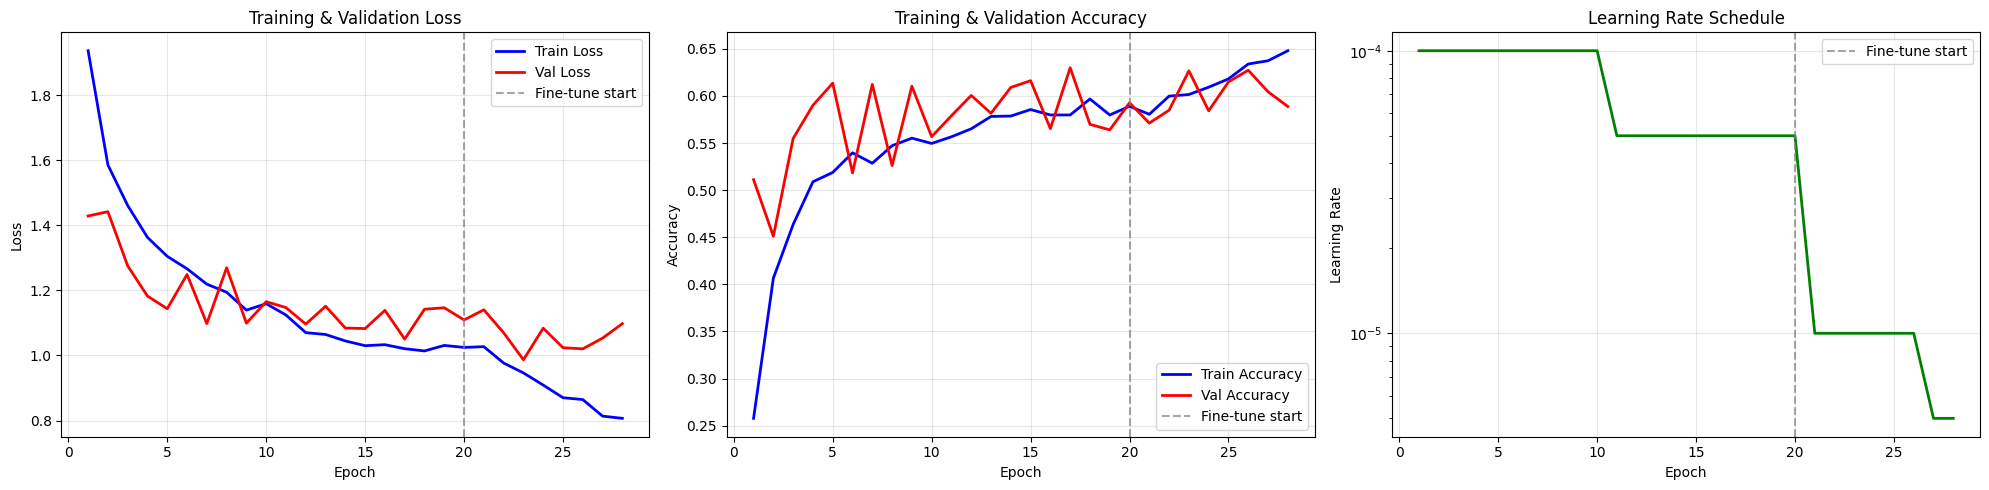

Saved: outputs/stage4_training_history.png


In [8]:
all_loss = history_phase1.history['loss'] + history_phase2.history['loss']
all_val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
all_acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
all_val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
all_lr = history_phase1.history['lr'] + history_phase2.history['lr']

total_epochs = len(all_loss)
phase1_end = phase1_epochs

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss
ax1 = axes[0]
ax1.plot(range(1, total_epochs+1), all_loss, 'b-', label='Train Loss', linewidth=2)
ax1.plot(range(1, total_epochs+1), all_val_loss, 'r-', label='Val Loss', linewidth=2)
ax1.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2 = axes[1]
ax2.plot(range(1, total_epochs+1), all_acc, 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(range(1, total_epochs+1), all_val_acc, 'r-', label='Val Accuracy', linewidth=2)
ax2.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Learning Rate
ax3 = axes[2]
ax3.plot(range(1, total_epochs+1), all_lr, 'g-', linewidth=2)
ax3.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_title('Learning Rate Schedule')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/stage4_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/stage4_training_history.png")

#### Evaluate on Test Set

In [9]:
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

test_accuracy = accuracy_score(y_true, y_pred)
test_loss = model.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Test Loss:     {test_loss[0]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

47/47 [==============================] - 7s 136ms/step
Test Loss:     1.0219
Test Accuracy: 0.6065 (60.65%)


#### Classification Report

In [10]:
target_names = [f"{idx_to_label[i]} ({CLASS_NAMES[idx_to_label[i]][:18]})" for i in range(NUM_CLASSES)]

report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)

with open('outputs/stage4_classification_report.txt', 'w') as f:
    f.write("CLASSIFICATION REPORT - Skin Lesion Classification")
    f.write(f"Model: MobileNetV2 Transfer Learning")
    f.write(f"Test Accuracy: {test_accuracy:.4f}")
    f.write(f"Test Loss: {test_loss[0]:.4f}")
    f.write(report)
print("Saved: outputs/stage4_classification_report.txt")

                           precision    recall  f1-score   support

akiec (Actinic keratosis)     0.2991    0.6154    0.4025        52
 bcc (Basal cell carcino)     0.5000    0.4648    0.4818        71
   bkl (Benign keratosis)     0.4312    0.2814    0.3406       167
      df (Dermatofibroma)     0.0915    0.6500    0.1605        20
           mel (Melanoma)     0.3252    0.5569    0.4106       167
    nv (Melanocytic nevi)     0.9185    0.6733    0.7770      1004
  vasc (Vascular lesions)     0.3036    0.8095    0.4416        21

                 accuracy                         0.6065      1502
                macro avg     0.4099    0.5788    0.4306      1502
             weighted avg     0.7375    0.6065    0.6479      1502

Saved: outputs/stage4_classification_report.txt


#### Confusion Matrix

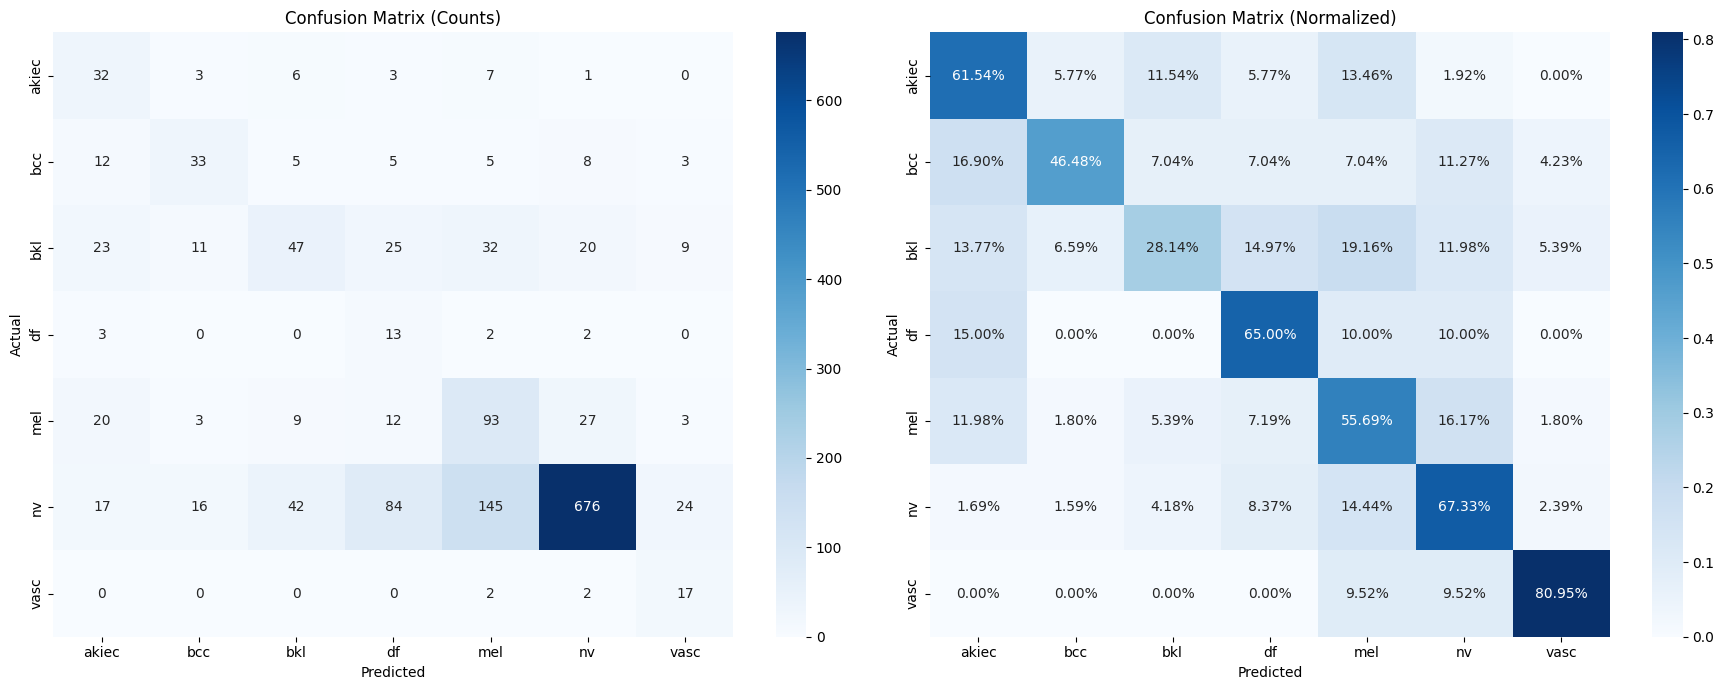

Saved: outputs/stage4_confusion_matrix.png


In [11]:
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=CLASSES_SORTED, yticklabels=CLASSES_SORTED)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix (Counts)')

ax2 = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
            xticklabels=CLASSES_SORTED, yticklabels=CLASSES_SORTED)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.savefig('../outputs/stage4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/stage4_confusion_matrix.png")

In [15]:
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)

#### ROC-AUC Curves

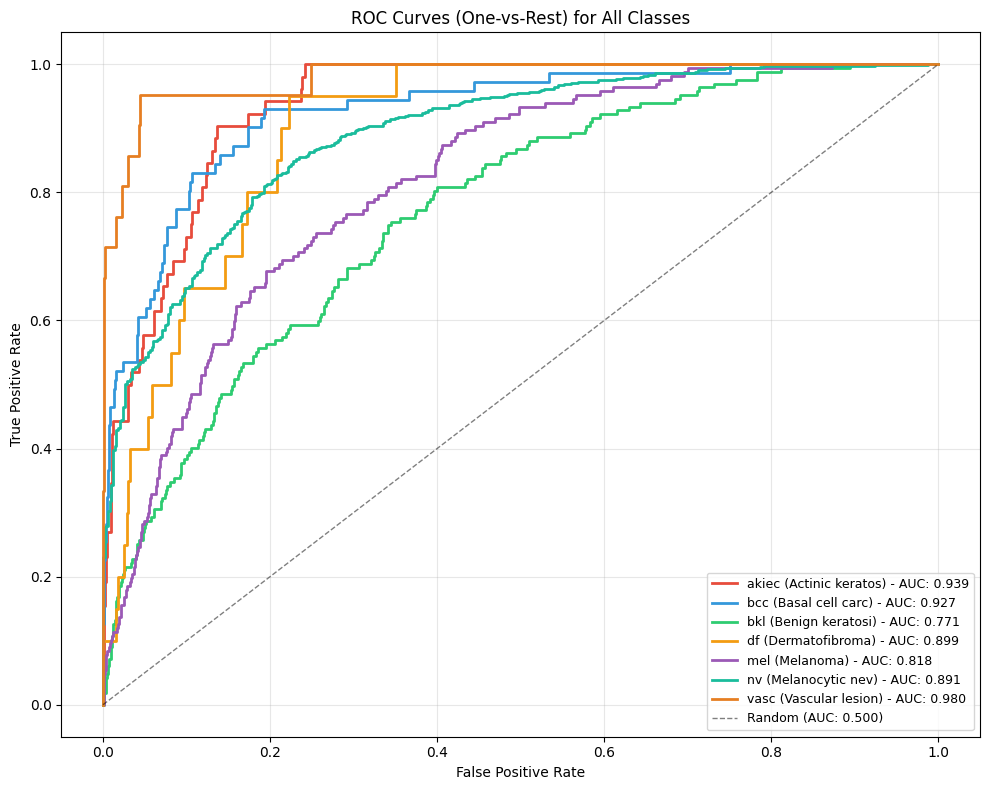

AUC Scores:
  vasc   (Vascular lesions         ): 0.9802
  akiec  (Actinic keratosis        ): 0.9389
  bcc    (Basal cell carcinoma     ): 0.9268
  df     (Dermatofibroma           ): 0.8995
  nv     (Melanocytic nevi         ): 0.8909
  mel    (Melanoma                 ): 0.8182
  bkl    (Benign keratosis         ): 0.7712
Mean AUC (macro): 0.8894


In [12]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22']
auc_scores = {}

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[idx_to_label[i]] = roc_auc
    ax.plot(fpr, tpr, color=colors[i], linewidth=2,
            label=f"{idx_to_label[i]} ({CLASS_NAMES[idx_to_label[i]][:15]}) - AUC: {roc_auc:.3f}")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC: 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (One-vs-Rest) for All Classes')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/stage4_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("AUC Scores:")
for cls, score in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cls:6s} ({CLASS_NAMES[cls]:25s}): {score:.4f}")

mean_auc = np.mean(list(auc_scores.values()))
print(f"Mean AUC (macro): {mean_auc:.4f}")

#### CONFIDENCE ANALYSIS


PREDICTION CONFIDENCE ANALYSIS
  Correct predictions: 911 (60.7%)
  Wrong predictions:   591 (39.3%)

  Avg confidence (correct): 0.7288
  Avg confidence (wrong):   0.5231


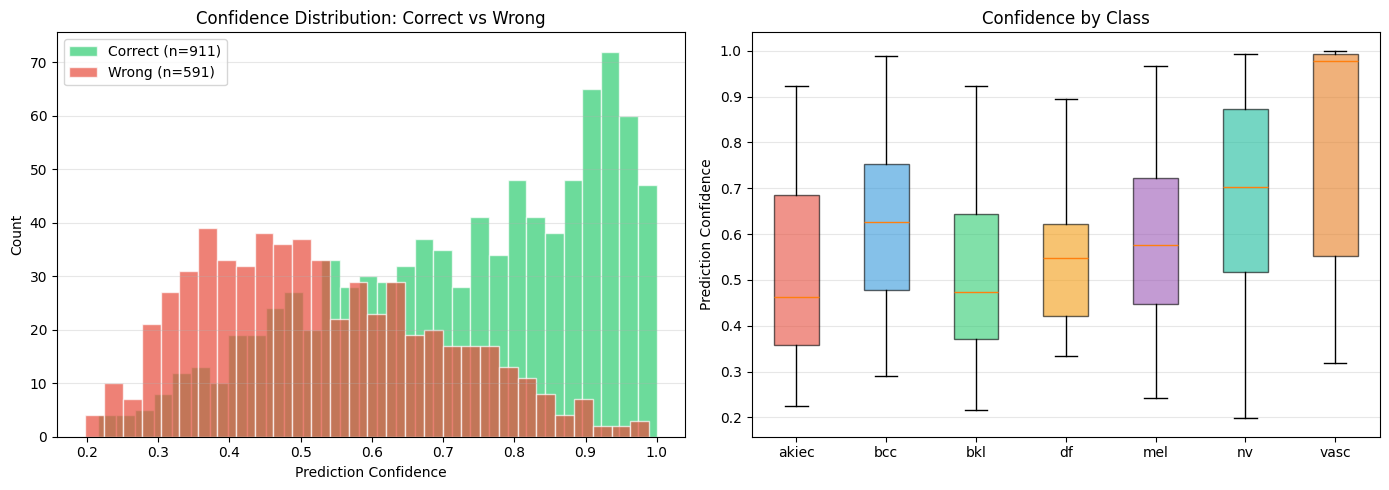

Saved: outputs/stage4_confidence_analysis.png


In [13]:
print("\n" + "=" * 60)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 60)
 
max_confidence = np.max(y_pred_proba, axis=1)
correct_mask = y_pred == y_true
 
correct_conf = max_confidence[correct_mask]
wrong_conf = max_confidence[~correct_mask]
 
print(f"  Correct predictions: {correct_mask.sum()} ({correct_mask.mean()*100:.1f}%)")
print(f"  Wrong predictions:   {(~correct_mask).sum()} ({(~correct_mask).mean()*100:.1f}%)")
print(f"\n  Avg confidence (correct): {correct_conf.mean():.4f}")
print(f"  Avg confidence (wrong):   {wrong_conf.mean():.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Confidence distribution
ax1 = axes[0]
ax1.hist(correct_conf, bins=30, alpha=0.7, color='#2ECC71', label=f'Correct (n={len(correct_conf)})', edgecolor='white')
ax1.hist(wrong_conf, bins=30, alpha=0.7, color='#E74C3C', label=f'Wrong (n={len(wrong_conf)})', edgecolor='white')
ax1.set_xlabel('Prediction Confidence')
ax1.set_ylabel('Count')
ax1.set_title('Confidence Distribution: Correct vs Wrong')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
 
# Confidence by class
ax2 = axes[1]
class_conf = []
for i in range(NUM_CLASSES):
    mask = y_true == i
    class_conf.append(max_confidence[mask])
 
bp = ax2.boxplot(class_conf, labels=CLASSES_SORTED, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel('Prediction Confidence')
ax2.set_title('Confidence by Class')
ax2.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('../outputs/stage4_confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/stage4_confidence_analysis.png")

####  MISCLASSIFICATION ANALYSIS (top errors)


TOP MISCLASSIFICATIONS

Top 10 highest-confidence WRONG predictions:
  #        True  Predicted   Confidence
  --------------------------------------
  1         bcc       vasc       0.9893
  2          nv       vasc       0.9891
  3          nv        mel       0.9794
  4          nv        mel       0.9616
  5          nv        bkl       0.9513
  6         bcc        mel       0.9318
  7         bkl        mel       0.9231
  8         bkl        mel       0.9086
  9         bkl        mel       0.8990
  10         nv        mel       0.8979


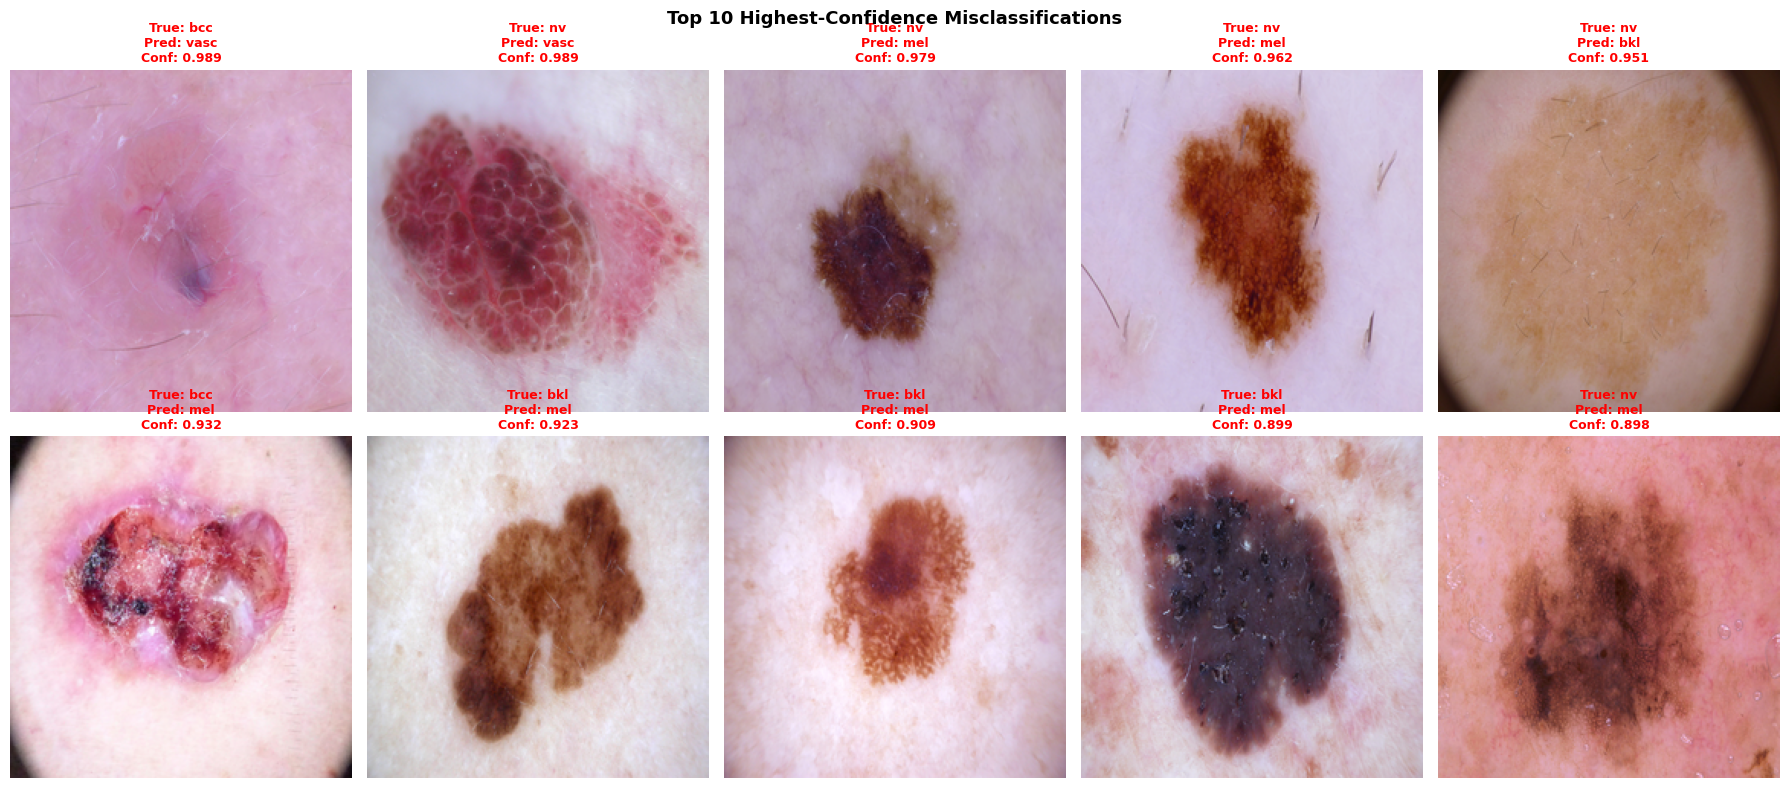

Saved: outputs/stage4_top_misclassifications.png


In [14]:
print("\n" + "=" * 60)
print("TOP MISCLASSIFICATIONS")
print("=" * 60)
 
wrong_indices = np.where(y_pred != y_true)[0]
wrong_conf_sorted = np.argsort(-max_confidence[wrong_indices])  # Highest confidence first
 
print(f"\nTop 10 highest-confidence WRONG predictions:")
print(f"  {'#':<4s} {'True':>8s} {'Predicted':>10s} {'Confidence':>12s}")
print("  " + "-" * 38)
 
for rank, idx in enumerate(wrong_conf_sorted[:10]):
    actual_idx = wrong_indices[idx]
    true_label = idx_to_label[y_true[actual_idx]]
    pred_label = idx_to_label[y_pred[actual_idx]]
    conf = max_confidence[actual_idx]
    print(f"  {rank+1:<4d} {true_label:>8s} {pred_label:>10s} {conf:>12.4f}")
 
# Visualize top misclassifications
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
 
for rank, idx in enumerate(wrong_conf_sorted[:10]):
    actual_idx = wrong_indices[idx]
    ax = axes[rank // 5][rank % 5]
    ax.imshow(X_test[actual_idx])
    ax.set_title(
        f"True: {idx_to_label[y_true[actual_idx]]}\n"
        f"Pred: {idx_to_label[y_pred[actual_idx]]}\n"
        f"Conf: {max_confidence[actual_idx]:.3f}",
        fontsize=9, color='red', fontweight='bold'
    )
    ax.axis('off')
 
plt.suptitle("Top 10 Highest-Confidence Misclassifications", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/stage4_top_misclassifications.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/stage4_top_misclassifications.png")


#### Saving Results 

In [16]:
np.savez_compressed("outputs/stage4_predictions.npz",
    y_pred=y_pred,
    y_pred_proba=y_pred_proba,
    y_true=y_true,
    correct_mask=correct_mask,
    wrong_indices=wrong_indices
)

metrics_summary = {
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss[0]),
    'mean_auc': float(mean_auc),
    'auc_scores': {k: float(v) for k, v in auc_scores.items()},
    'per_class_precision': {idx_to_label[i]: float(precision[i]) for i in range(NUM_CLASSES)},
    'per_class_recall': {idx_to_label[i]: float(recall[i]) for i in range(NUM_CLASSES)},
    'per_class_f1': {idx_to_label[i]: float(f1[i]) for i in range(NUM_CLASSES)},
    'phase1_epochs': phase1_epochs,
    'phase2_epochs': phase2_epochs,
    'total_epochs': total_epochs,
    'avg_confidence_correct': float(correct_conf.mean()),
    'avg_confidence_wrong': float(wrong_conf.mean()),
    'total_misclassifications': int((~correct_mask).sum())
}

with open('outputs/stage4_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved: outputs/stage4_predictions.npz")
print("Saved: outputs/stage4_metrics.json")

Saved: outputs/stage4_predictions.npz
Saved: outputs/stage4_metrics.json
